In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import json

with open('../data/airports.json') as f:
    airports = json.load(f)

with open('../data/routes.json') as f:
    routes = json.load(f)

In [3]:
airports_df = pd.DataFrame(airports)
routes_df = pd.DataFrame(routes)

In [4]:
airports_df.head()

,name,latitude,longitude
0,Innsbruck INN,47.2602,11.3440
1,Linz LNZ,48.2332,14.1875
2,Salzburg SZG,47.7933,13.0043
3,Vienna VIE,48.1103,16.5697
4,Klagenfurt KLU,46.6425,14.3377


In [ ]:
routes_df.head()

,src,dst,src_lat,src_lon,dst_lat,dst_lon
0,Innsbruck INN,London LGW,47.2602,11.3440,51.1481,-0.1903
1,Innsbruck INN,Amsterdam AMS,47.2602,11.3440,52.3086,4.7639
2,Linz LNZ,Bari BRI,48.2332,14.1875,41.1389,16.7606
3,Linz LNZ,Alicante ALC,48.2332,14.1875,38.2822,-0.5582
4,Linz LNZ,London STN,48.2332,14.1875,51.8850,0.2350


In [ ]:

airports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       301 non-null    object 
 1   latitude   301 non-null    float64
 2   longitude  301 non-null    float64
dtypes: float64(2), object(1)
memory usage: 7.2+ KB


## Dataset je kompletan bez nedostajucih vrednosti

In [ ]:

routes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8021 entries, 0 to 8020
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   src      8021 non-null   object 
 1   dst      8021 non-null   object 
 2   src_lat  8021 non-null   float64
 3   src_lon  8021 non-null   float64
 4   dst_lat  8021 non-null   float64
 5   dst_lon  8021 non-null   float64
dtypes: float64(4), object(2)
memory usage: 376.1+ KB


## U skupu podataka nalazi se 301 aerodroma

In [ ]:

len(airports_df)


301

## U skupu podataka nalazi se 8021 ruta

In [ ]:

len(routes_df)

8021

## Aerodrom London STN ima najveci broj polaznih ruta

In [ ]:

top_src = routes_df['src'].value_counts().head(10)
top_src

src
London STN        127
Barcelona BCN     119
Alicante ALC      119
Malaga AGP        117
Palma Mall PMI    112
Dublin DUB        110
Manchester MAN    107
London LGW        104
Brussels CRL      102
Oslo OSL          100
Name: count, dtype: int64

## Aerodrom London STN ima najveci broj odredista

In [ ]:

top_dst = routes_df['dst'].value_counts().head(10)
top_dst

dst
London STN        128
Barcelona BCN     124
Malaga AGP        119
Alicante ALC      118
Palma Mall PMI    114
Dublin DUB        113
Manchester MAN    107
London LGW        104
Brussels CRL      103
Oslo OSL          100
Name: count, dtype: int64

In [19]:
!pip install geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)

   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]



In [26]:
from geopy.distance import geodesic

def calculate_distance(row):
    return geodesic(
        (row['src_lat'], row['src_lon']),
        (row['dst_lat'], row['dst_lon'])
    ).km




In [27]:
routes_df['distance_km'] = routes_df.apply(calculate_distance, axis=1)

## Najkraca ruta u skupu podataka je izmedju aerodroma Belfast i Glasgow udaljena 167km

In [ ]:

shortest_route = routes_df.loc[routes_df['distance_km'].idxmin()]
shortest_route

src            Belfast BHD
dst            Glasgow GLA
src_lat            54.6181
src_lon            -5.8725
dst_lat            55.8719
dst_lon            -4.4331
distance_km     166.920052
Name: 7104, dtype: object

## Najduza ruta u skupu podataka je izmedju aerodroma Riga i Tenerife udaljena 4510km

In [ ]:

longest_routes = routes_df.loc[routes_df['distance_km'].idxmax()]
longest_routes

src                  Riga RIX
dst            Tenerife S TFS
src_lat               56.9236
src_lon               23.9711
dst_lat               28.0445
dst_lon              -16.5725
distance_km       4510.906439
Name: 3989, dtype: object

## Histogram pokazuje da vecina ruta spada u krace i srednje udaljenosti dok su duge rute redje

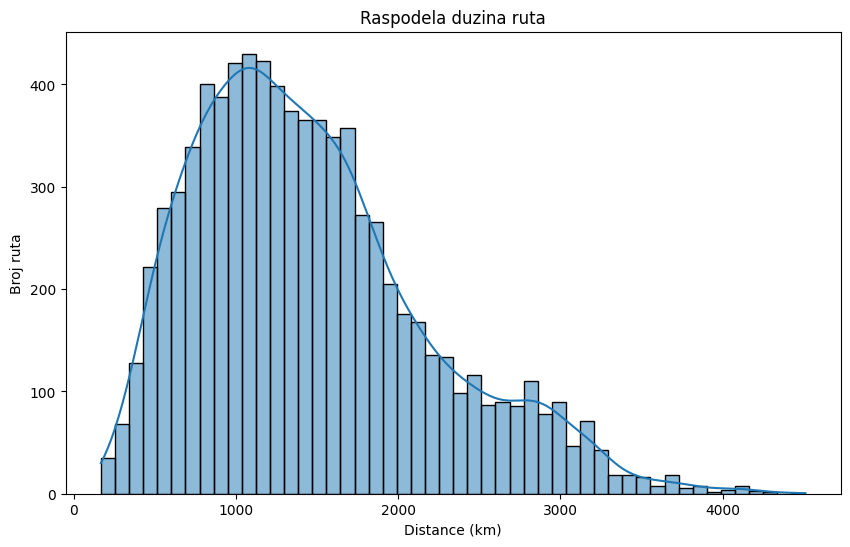

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(routes_df['distance_km'], bins=50, kde=True)

plt.title("Raspodela duzina ruta")
plt.xlabel("Distance (km)")
plt.ylabel("Broj ruta")

plt.show()

### Exploratory data analysis pokazuje da dataset sadrži 301 aerodrom i 8021 rutu, bez nedostajućih vrednosti. 
### Analiza pokazuje da su najaktivniji aerodromi veliki evropski hub-ovi poput Londona, Barselone i Dablina, koji se često pojavljuju i kao polazne i kao odredišne tačke. 
### Distribucija dužina ruta pokazuje da preovlađuju kraće i srednje distance, što ukazuje na dominantno regionalni karakter mreže letova.